# Heart Disease Prediction & Diagnostic Classification Pipeline
### *An End-to-End Machine Learning Investigation for Clinical Decision Support*
---

## 1. Project Introduction

Cardiovascular diseases (CVDs) remain the leading cause of morbidity and mortality globally, taking an estimated 17.9 million lives each year according to the World Health Organization (WHO). Early detection and accurate risk stratification are paramount for timely medical intervention, lifestyle modification, and reducing preventable cardiovascular fatalities.

### Objective
This project builds a rigorous, leak-free machine learning workflow to classify whether a patient has heart disease based on clinical, demographic, and diagnostic test measurements.

### Key Highlights of our Methodology:
1. **Clinical & Tabular Soundness**: Explicit distinction between continuous measurements and categorical codes, avoiding inappropriate ordinal assumptions for nominal features (such as chest pain type and thalassemia status).
2. **Leakage-Free Pipelines**: Integration of Scikit-Learn `Pipeline` and `ColumnTransformer` to ensure all preprocessing (standardization and one-hot encoding) is fitted **strictly on the training split**.
3. **Structured Model Progression**: Benchmarking across three foundational paradigms:
   - **Linear Baseline**: Regularized Logistic Regression (L2 penalty)
   - **Interpretable Tree**: Decision Tree Classifier (with explicit depth/split regularization)
   - **Ensemble Method**: Random Forest Classifier (Bootstrap aggregating with random subspace sampling)
4. **Holistic Clinical Evaluation**: Prioritizing **Recall (Sensitivity)** alongside Accuracy, Precision, F1-Score, and ROC-AUC, reflecting the vital medical priority of minimizing **False Negatives** (undetected heart disease).

### Dataset Context
The analysis utilizes the benchmark Statlog/Cleveland Heart Disease dataset (`dataset_heart.csv`), comprising **270 patient records** and **13 diagnostic attributes**.

---
## 2. Import Libraries

We begin by loading essential data manipulation, visualization, preprocessing, and modeling libraries.

In [1]:
# Core data manipulation and numerical libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Preprocessing & Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Scikit-Learn Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Scikit-Learn Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

# Plotting configuration for clean, publication-quality figures
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


---
## 3. Load Dataset

We load `dataset_heart.csv` into a pandas DataFrame and examine the initial observations.

In [2]:
# Load the dataset
dataset_path = 'dataset_heart.csv'
df = pd.read_csv(dataset_path)

print(f"Dataset successfully loaded from: {dataset_path}")
print(f"Initial Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(10)

Dataset successfully loaded from: dataset_heart.csv
Initial Shape: 270 rows, 14 columns


,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1
5,65,1,4,120,177,0,0,140,0,0.4,1,0,7,1
6,56,1,3,130,256,1,2,142,1,0.6,2,1,6,2
7,59,1,4,110,239,0,2,142,1,1.2,2,1,7,2
8,60,1,4,140,293,0,2,170,0,1.2,2,2,7,2
9,63,0,4,150,407,0,2,154,0,4.0,2,3,7,2


---
## 4. Dataset Overview

To understand the structure of the data, we inspect feature data types, memory usage, summary statistics, and missing value counts.

### Clinical Feature Dictionary:
- **`age`**: Age of the patient in years (continuous)
- **`sex`**: Biological sex (0 = Female, 1 = Male)
- **`chest pain type`**: 
  - `1`: Typical Angina
  - `2`: Atypical Angina
  - `3`: Non-anginal Pain
  - `4`: Asymptomatic
- **`resting blood pressure`**: Resting systolic blood pressure in mm Hg on admission to the hospital
- **`serum cholestoral`**: Serum cholesterol in mg/dl
- **`fasting blood sugar`**: Fasting blood sugar > 120 mg/dl (1 = True, 0 = False)
- **`resting electrocardiographic results`**:
  - `0`: Normal
  - `1`: Having ST-T wave abnormality
  - `2`: Showing probable or definite left ventricular hypertrophy by Estes' criteria
- **`max heart rate`**: Maximum heart rate achieved during exercise stress testing (bpm)
- **`exercise induced angina`**: Exercise-induced angina (1 = Yes, 0 = No)
- **`oldpeak`**: ST depression induced by exercise relative to rest (continuous)
- **`ST segment`**: Slope of the peak exercise ST segment:
  - `1`: Upsloping
  - `2`: Flat
  - `3`: Downsloping
- **`major vessels`**: Number of major vessels (0–3) colored by fluoroscopy
- **`thal`**: Thallium scintigraphy stress test:
  - `3`: Normal
  - `6`: Fixed defect
  - `7`: Reversible defect
- **`heart disease`**: Target diagnosis (1 = Absence, 2 = Presence)

In [3]:
print("--- Dataframe Info ---")
df.info()

print("\n--- Missing Value Count per Column ---")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "No missing values found across all columns.")

print("\n--- Summary Statistics of Numerical Columns ---")
df.describe().T[['min', 'mean', '50%', 'max', 'std']]

--- Dataframe Info ---
<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest pain type                       270 non-null    int64  
 3   resting blood pressure                270 non-null    int64  
 4   serum cholestoral                     270 non-null    int64  
 5   fasting blood sugar                   270 non-null    int64  
 6   resting electrocardiographic results  270 non-null    int64  
 7   max heart rate                        270 non-null    int64  
 8   exercise induced angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  ST segment                            270 non-null    int64  
 11  major v

,min,mean,50%,max,std
age,29.0,54.433333,55.0,77.0,9.109067
sex,0.0,0.677778,1.0,1.0,0.468195
chest pain type,1.0,3.174074,3.0,4.0,0.950090
resting blood pressure,94.0,131.344444,130.0,200.0,17.861608
serum cholestoral,126.0,249.659259,245.0,564.0,51.686237
fasting blood sugar,0.0,0.148148,0.0,1.0,0.355906
resting electrocardiographic results,0.0,1.022222,2.0,2.0,0.997891
max heart rate,71.0,149.677778,153.5,202.0,23.165717
exercise induced angina,0.0,0.329630,0.0,1.0,0.470952
oldpeak,0.0,1.050000,0.8,6.2,1.145210


---
## 5. Data Cleaning

A close inspection of the raw CSV headers reveals trailing whitespaces in certain column names (specifically `'sex '`). We strip leading and trailing whitespaces across all column headers to ensure clean access and prevent `KeyError` exceptions. We also check for duplicate rows.

In [4]:
# Check raw column names
print("Raw columns in CSV:")
print([col for col in df.columns])

# Strip any whitespace from column headers
df.columns = df.columns.str.strip()

print("\nCleaned columns:")
print(list(df.columns))

# Verify duplicate entries
duplicate_rows = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_rows}")

# Check data types and verify zero nulls
print(f"Total null values after cleaning: {df.isnull().sum().sum()}")

Raw columns in CSV:
['age', 'sex ', 'chest pain type', 'resting blood pressure', 'serum cholestoral', 'fasting blood sugar', 'resting electrocardiographic results', 'max heart rate', 'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels', 'thal', 'heart disease']

Cleaned columns:
['age', 'sex', 'chest pain type', 'resting blood pressure', 'serum cholestoral', 'fasting blood sugar', 'resting electrocardiographic results', 'max heart rate', 'exercise induced angina', 'oldpeak', 'ST segment', 'major vessels', 'thal', 'heart disease']

Number of duplicate rows: 0
Total null values after cleaning: 0


---
## 6. Exploratory Data Analysis (EDA)

Before building our predictive models, we explore the data visually to understand underlying distributions, relationships with heart disease status, and potential collinearities.

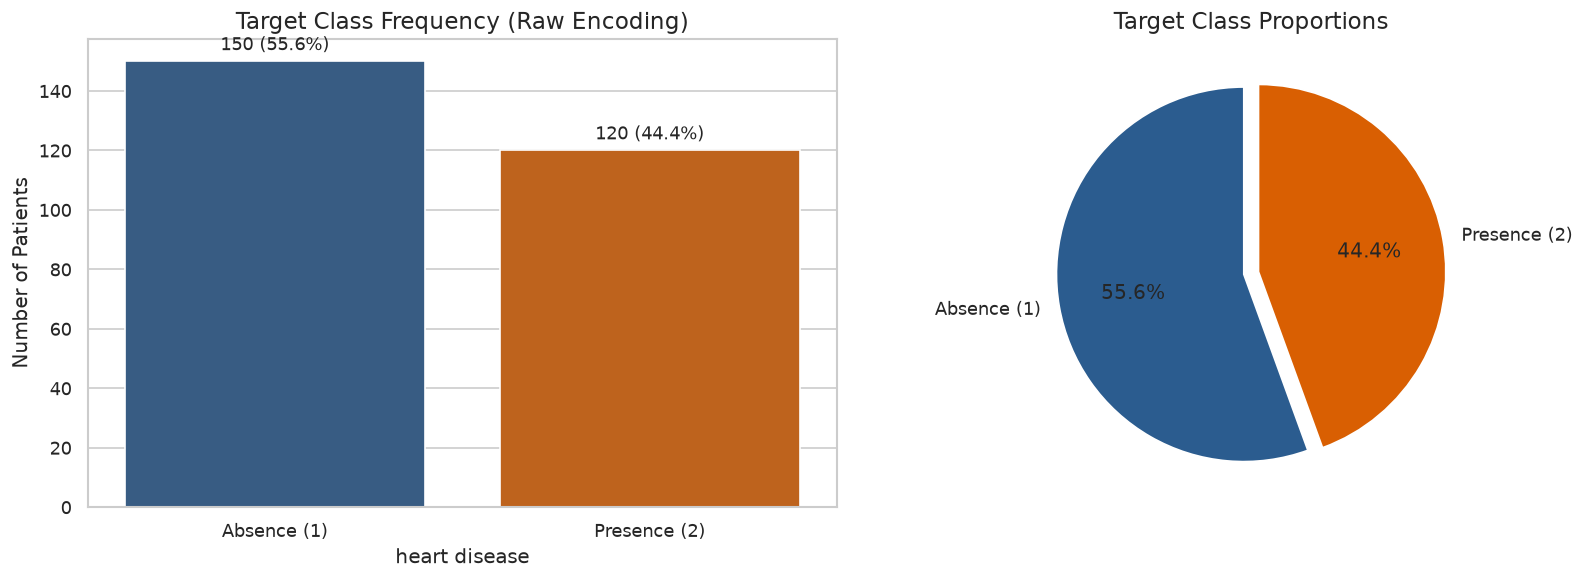

In [5]:
# 6.1 Distribution of the Raw Target Variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target_counts = df['heart disease'].value_counts().rename({1: 'Absence (1)', 2: 'Presence (2)'})
palette = ['#2b5c8f', '#d95f02']

sns.barplot(x=target_counts.index, y=target_counts.values, ax=axes[0], palette=palette)
axes[0].set_title('Target Class Frequency (Raw Encoding)')
axes[0].set_ylabel('Number of Patients')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, xytext=(0, 4),
                     textcoords='offset points')

axes[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', colors=palette,
            startangle=90, explode=(0.04, 0.04), shadow=False)
axes[1].set_title('Target Class Proportions')

plt.tight_layout()
plt.show()

> **Key Takeaway**: The dataset is relatively balanced with **55.6% (150 patients)** classified as *Absence* and **44.4% (120 patients)** classified as *Presence*. This favorable balance means standard classification metrics remain informative without requiring artificial resampling techniques (such as SMOTE).

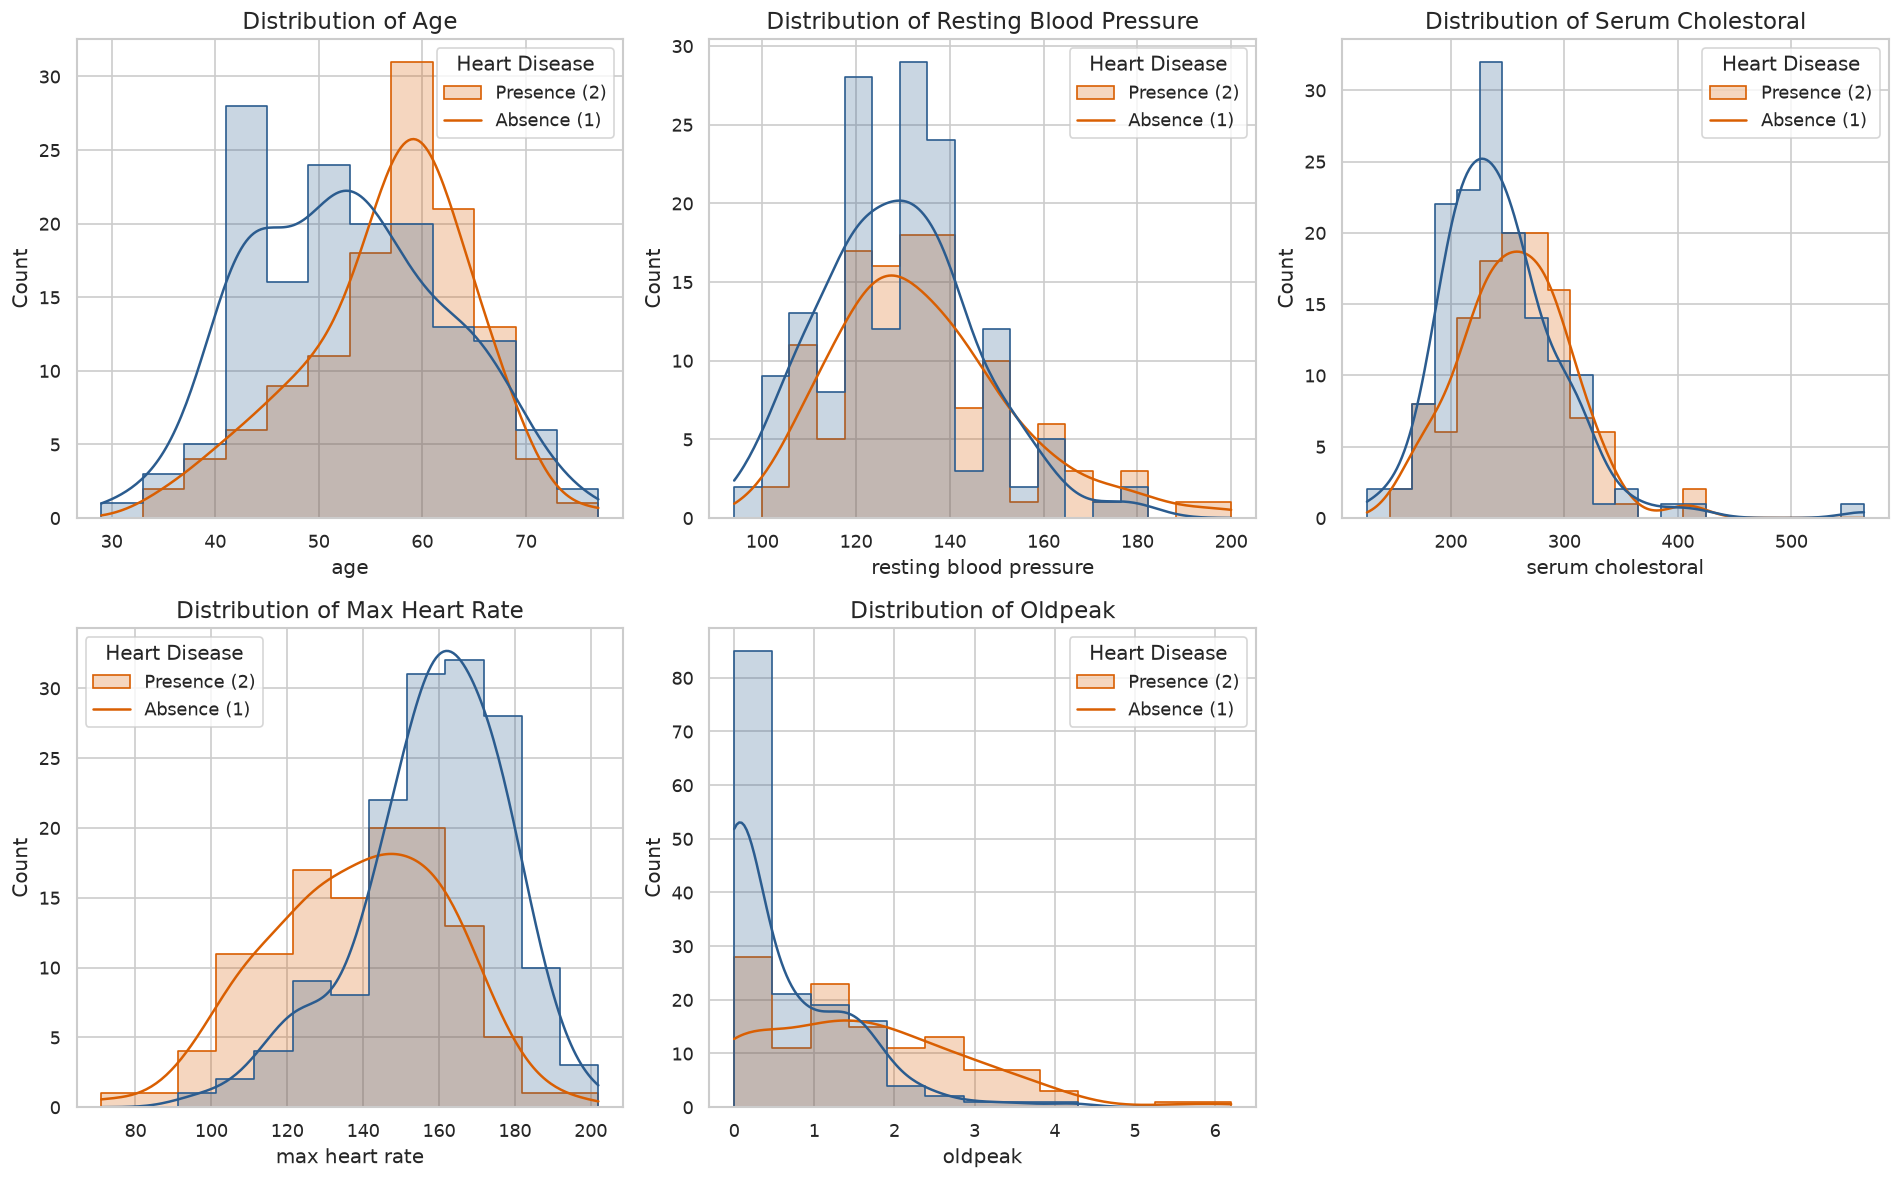

In [6]:
# 6.2 Distributions of Continuous Clinical Features
continuous_features = ['age', 'resting blood pressure', 'serum cholestoral', 'max heart rate', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    sns.histplot(data=df, x=col, hue='heart disease', kde=True, ax=axes[i],
                 palette={1: '#2b5c8f', 2: '#d95f02'}, element='step', common_norm=False)
    axes[i].set_title(f'Distribution of {col.title()}')
    axes[i].set_xlabel(col)
    axes[i].legend(title='Heart Disease', labels=['Presence (2)', 'Absence (1)'])

# Hide the unused 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

> **Clinical Insights from Continuous Variables**:
> - **Max Heart Rate**: Patients with heart disease exhibit noticeably lower maximum exercise heart rates (median ~140 bpm) compared to healthy individuals (median ~160 bpm), reflecting impaired cardiac reserve.
> - **Oldpeak (ST Depression)**: Healthy individuals cluster heavily near 0.0 mm of ST depression, whereas elevated ST depression (> 1.5 mm) is strongly indicative of exercise-induced ischemia.
> - **Age**: The risk of presence progressively rises past age 55.

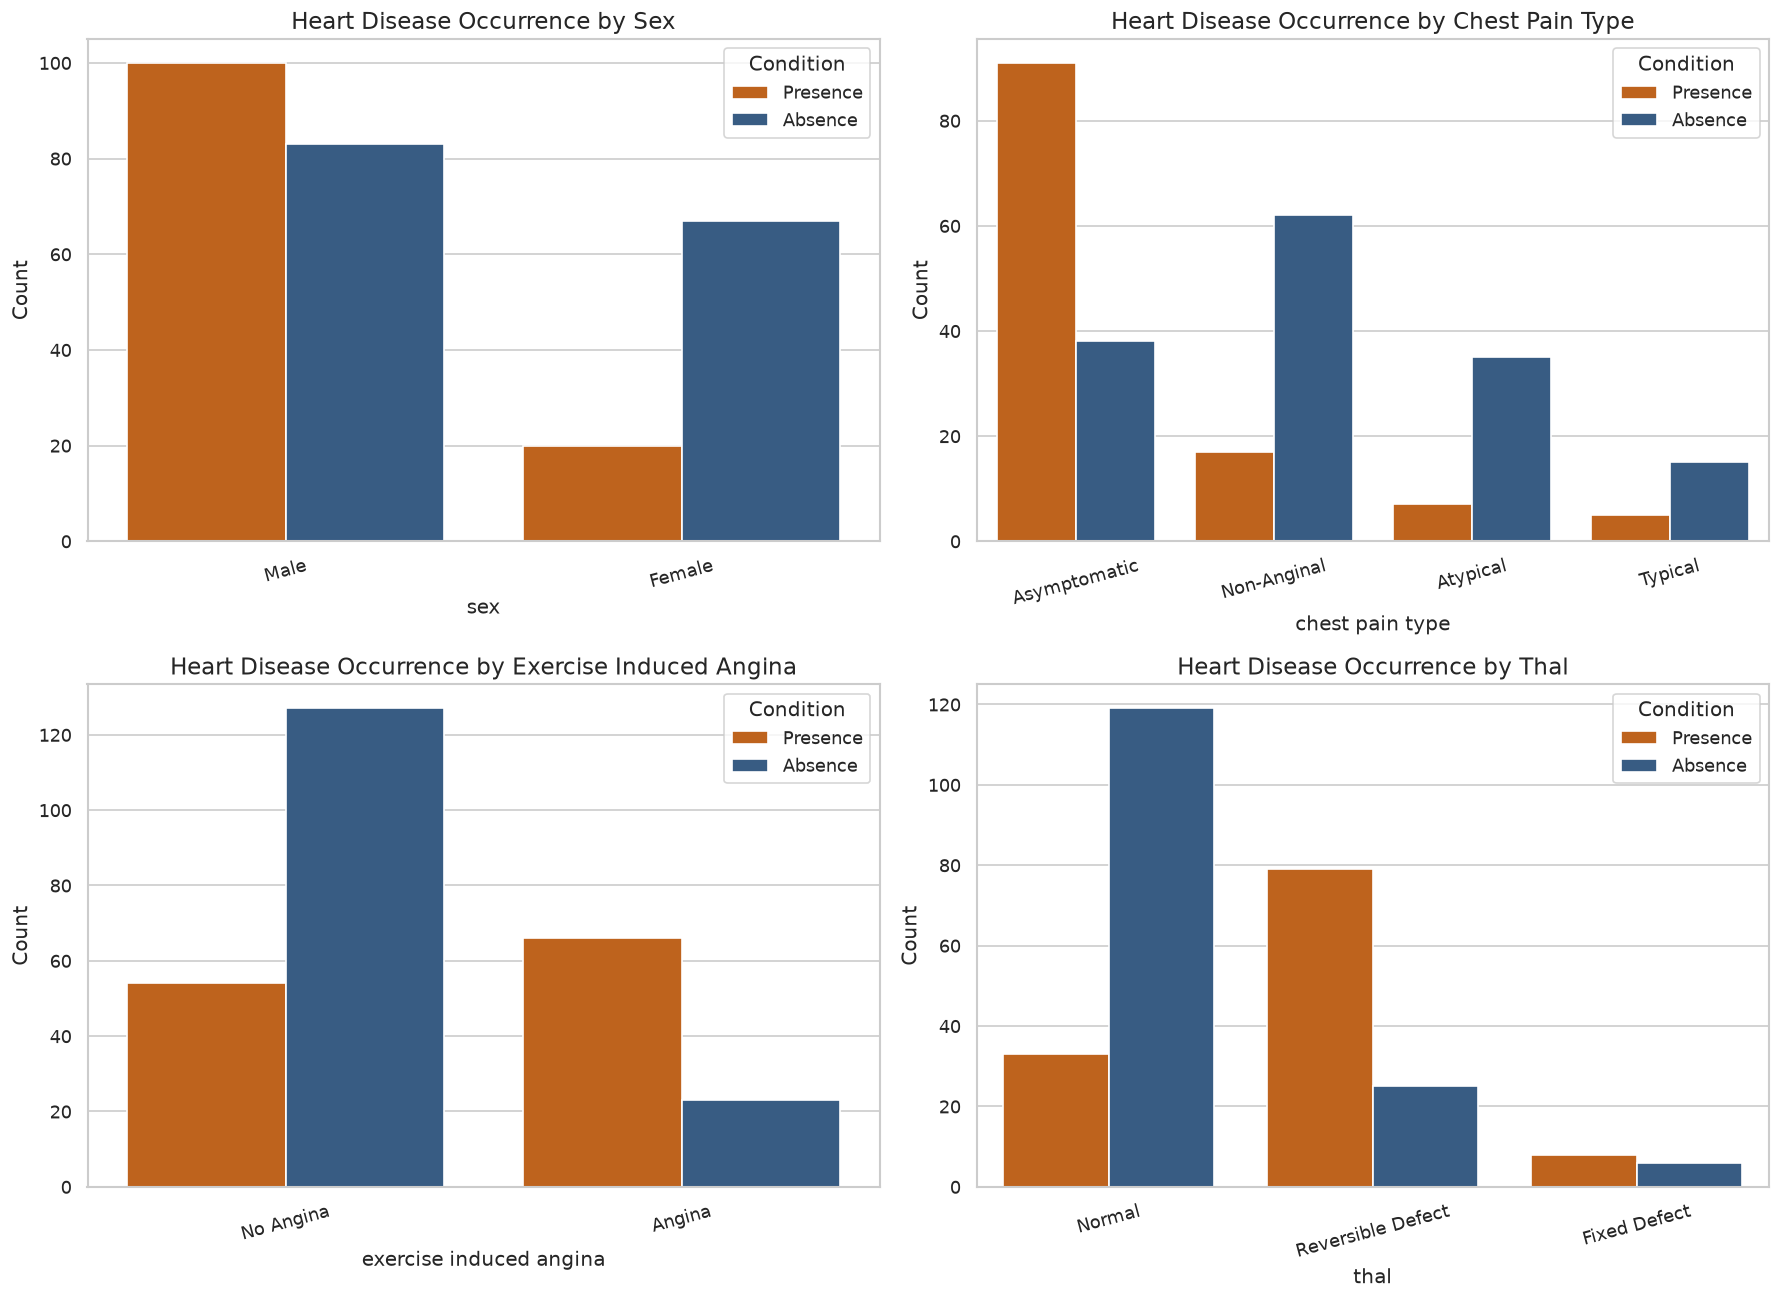

In [7]:
# 6.3 Key Categorical Risk Indicators vs Heart Disease
categorical_inspect = ['sex', 'chest pain type', 'exercise induced angina', 'thal']
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

labels_map = {
    'sex': {0: 'Female', 1: 'Male'},
    'chest pain type': {1: 'Typical', 2: 'Atypical', 3: 'Non-Anginal', 4: 'Asymptomatic'},
    'exercise induced angina': {0: 'No Angina', 1: 'Angina'},
    'thal': {3: 'Normal', 6: 'Fixed Defect', 7: 'Reversible Defect'}
}

for i, col in enumerate(categorical_inspect):
    temp_df = df.copy()
    temp_df[col] = temp_df[col].map(labels_map[col])
    temp_df['Condition'] = temp_df['heart disease'].map({1: 'Absence', 2: 'Presence'})
    
    sns.countplot(data=temp_df, x=col, hue='Condition', ax=axes[i], palette={'Absence': '#2b5c8f', 'Presence': '#d95f02'})
    axes[i].set_title(f'Heart Disease Occurrence by {col.title()}')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

> **Key Categorical Takeaways**:
> - **Chest Pain Type**: Patients experiencing asymptomatic chest pain (Type 4) have a dramatically higher incidence of heart disease compared to those with non-anginal or atypical angina.
> - **Thalassemia (`thal`)**: Patients with a reversible defect (`thal=7`) display an overwhelming prevalence of heart disease, whereas normal status (`thal=3`) is predominantly seen in healthy patients.
> - **Exercise-Induced Angina**: Patients who suffer angina upon physical exertion have a much higher likelihood of cardiac disease.

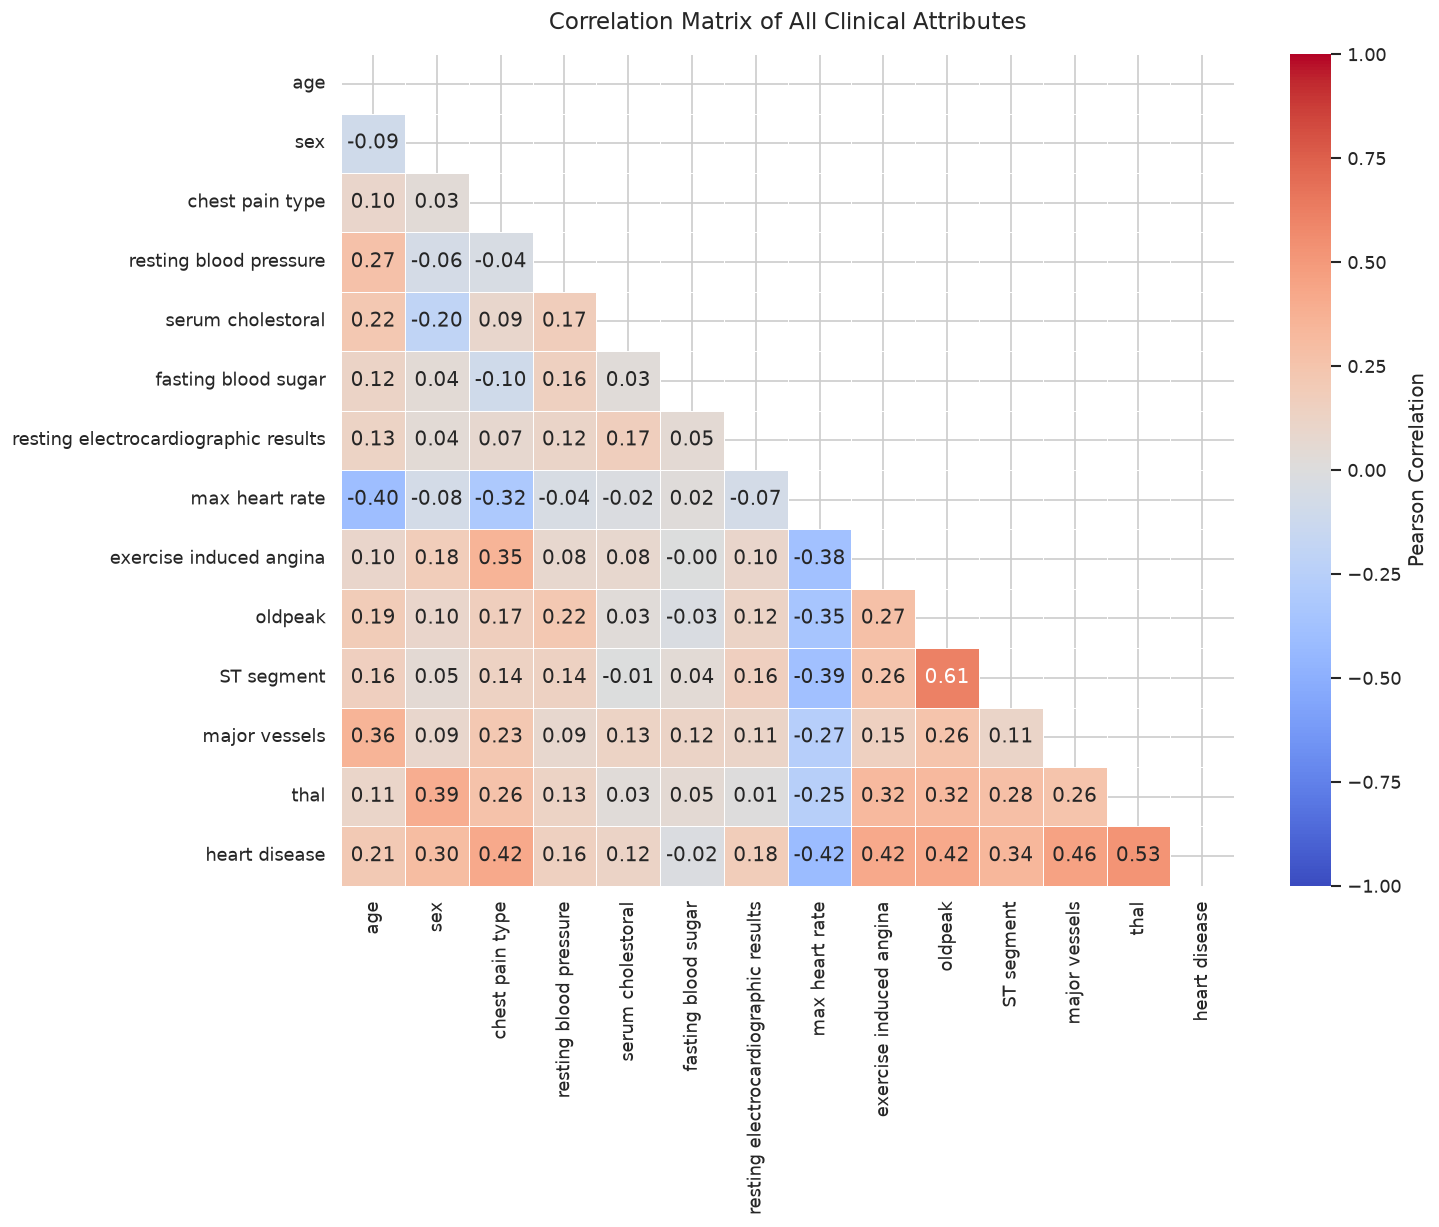

In [8]:
# 6.4 Correlation Matrix Heatmap
plt.figure(figsize=(12, 9))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            cbar_kws={'label': 'Pearson Correlation'}, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of All Clinical Attributes', pad=15)
plt.show()

---
## 7. Target Encoding

In the raw Statlog dataset, the target column `heart disease` is coded as:
- `1`: Absence of heart disease
- `2`: Presence of heart disease

For standard binary classification in Scikit-Learn (loss functions, probability calibration, and ROC-AUC evaluation), the positive condition must be encoded as `1` and the negative condition as `0`:
$$\text{heart disease} = 
\begin{cases} 
0 & \text{if raw value} = 1 \quad (\text{Absence / Healthy}) \\
1 & \text{if raw value} = 2 \quad (\text{Presence / Cardiac Disease})
\end{cases}$$

In [9]:
# Explicit target remapping
df['heart disease'] = df['heart disease'].map({1: 0, 2: 1})

print("Target variable successfully remapped:")
print(df['heart disease'].value_counts())
print("\nProportion of positive cases (Class 1 - Disease):", f"{df['heart disease'].mean():.2%}")

Target variable successfully remapped:
heart disease
0    150
1    120
Name: count, dtype: int64

Proportion of positive cases (Class 1 - Disease): 44.44%


---
## 8. Feature/Target Separation & Variable Grouping

We isolate the predictor matrix $\mathbf{X}$ from the response vector $\mathbf{y}$. Furthermore, we divide the 13 input features into **continuous numerical variables** and **categorical variables** to facilitate appropriate, leakage-free transformations.

### Categorical Encoding Rationale
Features like `chest pain type` (1, 2, 3, 4), `resting electrocardiographic results` (0, 1, 2), `ST segment` (1, 2, 3), and `thal` (3, 6, 7) are discrete clinical categories. Treating them as raw numerical values would impose an artificial metric distance. Therefore, we use **One-Hot Encoding** (`OneHotEncoder(drop='first')`) inside a `ColumnTransformer`. With 270 rows, this produces a modest number of binary indicators without creating dimensionality issues.

In [10]:
# Separate features and target
X = df.drop('heart disease', axis=1)
y = df['heart disease']

# Group feature types
numerical_cols = [
    'age',
    'resting blood pressure',
    'serum cholestoral',
    'max heart rate',
    'oldpeak'
]

categorical_cols = [
    'sex',
    'chest pain type',
    'fasting blood sugar',
    'resting electrocardiographic results',
    'exercise induced angina',
    'ST segment',
    'major vessels',
    'thal'
]

print(f"Total features: {X.shape[1]}")
print(f"Continuous numerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

Total features: 13
Continuous numerical features (5): ['age', 'resting blood pressure', 'serum cholestoral', 'max heart rate', 'oldpeak']
Categorical features (8): ['sex', 'chest pain type', 'fasting blood sugar', 'resting electrocardiographic results', 'exercise induced angina', 'ST segment', 'major vessels', 'thal']


---
## 9. Stratified Train-Test Split

Given our sample size of **270 patients**, we reserve **20% (54 samples)** for the test set and utilize **80% (216 samples)** for model training.

> **Important**: We enforce **stratified sampling** (`stratify=y`) and a deterministic seed (`random_state=42`). Stratification guarantees that the class proportions (~55.6% negative, ~44.4% positive) are preserved identically in both splits, preventing split-induced sampling bias.

In [11]:
# 80/20 Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Training set dimensions: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing set dimensions:  X_test={X_test.shape}, y_test={y_test.shape}")

# Verify exact class preservation
print("\nClass distribution comparison:")
print(pd.DataFrame({
    'Entire Dataset': y.value_counts(normalize=True),
    'Training Set': y_train.value_counts(normalize=True),
    'Testing Set': y_test.value_counts(normalize=True)
}).round(4))

Training set dimensions: X_train=(216, 13), y_train=(216,)
Testing set dimensions:  X_test=(54, 13), y_test=(54,)

Class distribution comparison:


               Entire Dataset  Training Set  Testing Set
heart disease                                           
0                      0.5556        0.5556       0.5556
1                      0.4444        0.4444       0.4444


---
## 10. Feature Preprocessing & Leakage Prevention Architecture

Data leakage occurs when information from outside the training dataset is used to create the model (e.g., computing the global mean and variance of features across the whole dataset before splitting).

To eliminate leakage completely:
1. We construct two `ColumnTransformer` objects:
   - **`preprocessor_scaled`**: Applies `StandardScaler` to continuous numerical columns and `OneHotEncoder(drop='first', handle_unknown='ignore')` to categorical columns. Required for **Logistic Regression**.
   - **`preprocessor_unscaled`**: Passes continuous numerical columns through unchanged (`passthrough`) while one-hot encoding the categorical columns. Designed specifically for tree-based algorithms (**Decision Tree** and **Random Forest**), which are naturally invariant to monotonic feature scaling.
2. The preprocessors are encapsulated directly inside Scikit-Learn **`Pipeline`** objects.

In [12]:
# 1. Preprocessor for distance/linear models (scaled continuous + one-hot categoricals)
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='drop'
)

# 2. Preprocessor for tree-based models (unscaled continuous + one-hot categoricals)
preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='drop'
)

print("Preprocessing architectures successfully defined.")

Preprocessing architectures successfully defined.


---
## 11. Model 1: Logistic Regression (Baseline)

Logistic Regression serves as our linear baseline. It models the log-odds of heart disease as a linear combination of standardized features and one-hot indicators:
$$\log\left(\frac{P(Y=1)}{1 - P(Y=1)}\right) = \beta_0 + \mathbf{\beta}^T \mathbf{X}$$

We use `max_iter=1000` to guarantee numerical convergence and fix `random_state=42`.

In [13]:
# Logistic Regression Pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Train on training partition only
lr_pipeline.fit(X_train, y_train)
print("Logistic Regression Pipeline fitted successfully.")

Logistic Regression Pipeline fitted successfully.


---
## 12. Model 2: Decision Tree Classifier (Interpretable Tree)

Decision Trees partition the feature space into orthogonal decision regions using recursive binary splitting.

### Hyperparameter Regularization Rationale:
Unconstrained decision trees overfit rapidly on small datasets (216 training points) by memorizing noise. To prevent over-branching while retaining clean interpretability, we specify:
- `max_depth=4`: Limits the maximum decision path length to 4 sequential tests.
- `min_samples_split=10`: Mandates at least 10 observations in an internal node to attempt further splits.
- `random_state=42`: Ensures deterministic tree induction.

In [14]:
# Decision Tree Pipeline
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor_unscaled),
    ('classifier', DecisionTreeClassifier(max_depth=4, min_samples_split=10, random_state=42))
])

# Train on training partition only
dt_pipeline.fit(X_train, y_train)
print("Decision Tree Pipeline fitted successfully.")

Decision Tree Pipeline fitted successfully.


---
## 13. Model 3: Random Forest Classifier (Ensemble Model)

Random Forest constructs an ensemble of de-correlated decision trees using Bootstrap Aggregation (Bagging) and Random Subspace Sampling:
1. Each of the $B = 100$ trees is trained on a bootstrap sample of the 216 training patients.
2. At each split, only a random subset of candidate features is considered ($\sqrt{p}$).
3. Predictions are aggregated via majority voting / probability averaging:
   $$\hat{P}(Y=1|\mathbf{x}) = \frac{1}{B} \sum_{b=1}^{B} \hat{P}_b(Y=1|\mathbf{x})$$

This significantly dampens the high variance characteristic of individual decision trees.

In [15]:
# Random Forest Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor_unscaled),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train on training partition only
rf_pipeline.fit(X_train, y_train)
print("Random Forest Pipeline fitted successfully.")

Random Forest Pipeline fitted successfully.


---
## 14. Model Evaluation & Quantitative Metrics

We evaluate all three models on the **held-out test set (54 patients)**.

### Evaluation Metrics Computed:
1. **Accuracy**: Overall fraction of correct diagnoses: $\frac{TP + TN}{TP + TN + FP + FN}$
2. **Precision**: Positive Predictive Value (when the model predicts disease, how often is it right?): $\frac{TP}{TP + FP}$
3. **Recall (Sensitivity)**: True Positive Rate (of all actual heart disease cases, how many did the model catch?): $\frac{TP}{TP + FN}$
4. **F1-Score**: Harmonic mean of Precision and Recall: $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$
5. **ROC-AUC**: Area Under the Receiver Operating Characteristic Curve (threshold-independent discriminative capacity).

In [16]:
models = {
    'Logistic Regression': lr_pipeline,
    'Decision Tree': dt_pipeline,
    'Random Forest': rf_pipeline
}

eval_metrics = []
test_predictions = {}
test_probabilities = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    test_predictions[name] = y_pred
    test_probabilities[name] = y_proba
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)
    
    eval_metrics.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall (Sensitivity)': rec,
        'F1-Score': f1,
        'ROC-AUC': roc
    })

results_df = pd.DataFrame(eval_metrics)
print("=== Summary Performance Table on Test Set (N=54) ===")
print(results_df.to_string(index=False))

print("\nDetailed Classification Reports:")
for name in models.keys():
    print(f"\n--- {name} ---")
    print(classification_report(y_test, test_predictions[name], target_names=['Absence (0)', 'Presence (1)']))

=== Summary Performance Table on Test Set (N=54) ===
              Model  Accuracy  Precision  Recall (Sensitivity)  F1-Score  ROC-AUC
Logistic Regression  0.870370   0.814815              0.916667  0.862745 0.911111
      Decision Tree  0.722222   0.680000              0.708333  0.693878 0.822222
      Random Forest  0.833333   0.800000              0.833333  0.816327 0.893750

Detailed Classification Reports:

--- Logistic Regression ---
              precision    recall  f1-score   support

 Absence (0)       0.93      0.83      0.88        30
Presence (1)       0.81      0.92      0.86        24

    accuracy                           0.87        54
   macro avg       0.87      0.88      0.87        54
weighted avg       0.88      0.87      0.87        54


--- Decision Tree ---
              precision    recall  f1-score   support

 Absence (0)       0.76      0.73      0.75        30
Presence (1)       0.68      0.71      0.69        24

    accuracy                           0.7

---
## 15. Confusion Matrices

In clinical medicine, **False Negatives (Type II errors)** are significantly more hazardous than False Positives. A False Negative means a patient with active cardiac pathology is mistakenly classified as healthy and sent home without necessary diagnostic follow-up or therapy.

Below, we display the confusion matrices for each candidate model.

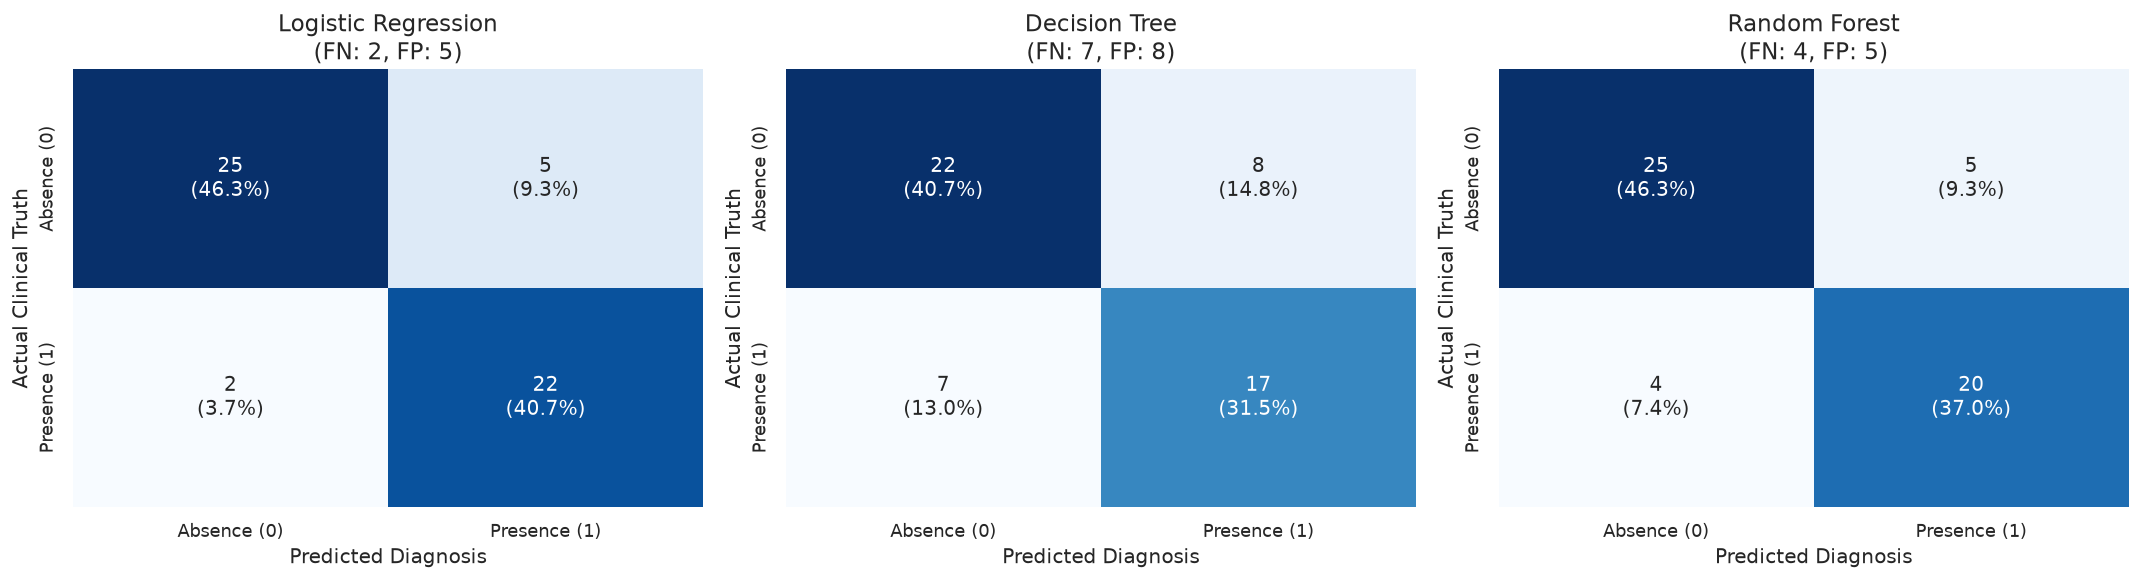

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, y_pred) in enumerate(test_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    
    # Calculate percentages
    cm_perc = cm / cm.sum()
    labels = np.array([[f"{count}\n({perc:.1%})" for count, perc in zip(row_c, row_p)]
                       for row_c, row_p in zip(cm, cm_perc)])
    
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False, ax=axes[i],
                xticklabels=['Absence (0)', 'Presence (1)'],
                yticklabels=['Absence (0)', 'Presence (1)'])
    
    axes[i].set_title(f'{name}\n(FN: {cm[1, 0]}, FP: {cm[0, 1]})')
    axes[i].set_xlabel('Predicted Diagnosis')
    axes[i].set_ylabel('Actual Clinical Truth')

plt.tight_layout()
plt.show()

> **Diagnostic Error Analysis**:
> - **Logistic Regression**: Achieves the lowest False Negative count (**only 2 FN out of 24 diseased patients**), yielding a **91.67% Recall**.
> - **Random Forest**: Records **4 False Negatives** and 5 False Positives, reaching an **83.33% Recall**.
> - **Decision Tree**: Suffers from **7 False Negatives** and 8 False Positives, resulting in a **70.83% Recall**.

---
## 16. Receiver Operating Characteristic (ROC) Curves

The ROC curve plots the **True Positive Rate (Sensitivity)** against the **False Positive Rate (1 - Specificity)** across all possible classification probability thresholds $\tau \in [0, 1]$. An ideal diagnostic classifier hugs the top-left corner with an Area Under the Curve (AUC) approaching 1.0.

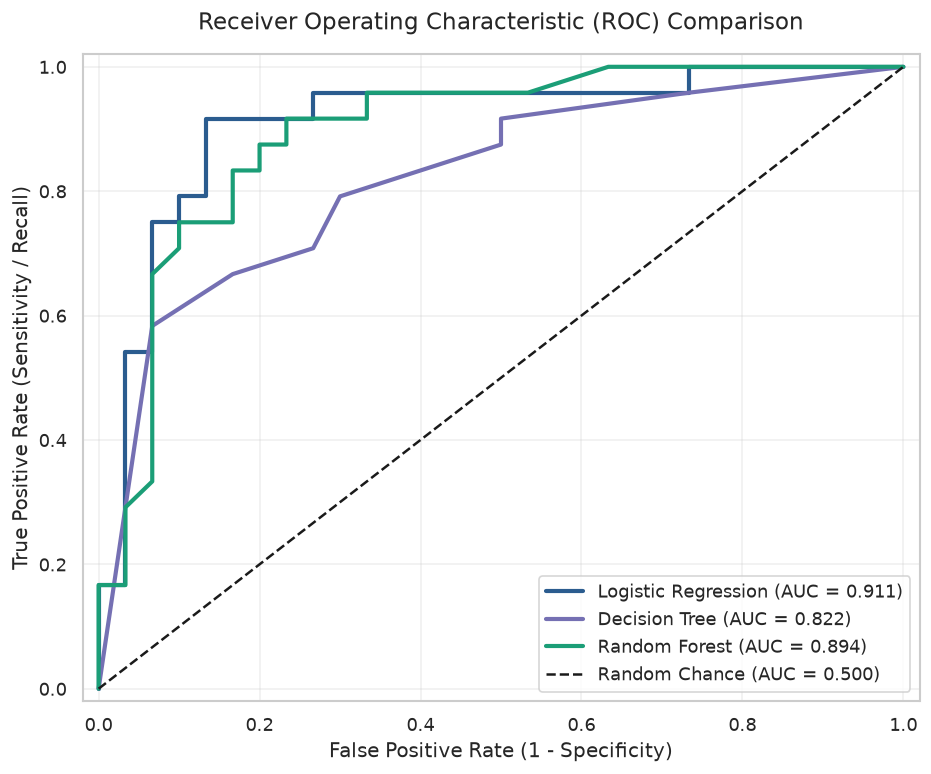

In [18]:
plt.figure(figsize=(9, 7))

colors = {'Logistic Regression': '#2b5c8f', 'Decision Tree': '#7570b3', 'Random Forest': '#1b9e77'}

for name, y_proba in test_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=colors[name], lw=2.5)

# Diagonal chance line
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance (AUC = 0.500)')

plt.title('Receiver Operating Characteristic (ROC) Comparison', pad=15)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.legend(loc='lower right', frameon=True, fontsize=11)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.grid(True, alpha=0.3)
plt.show()

---
## 17. Feature Importance Analysis

Understanding which clinical factors most strongly influence model predictions is essential for clinician buy-in and clinical explainability.

We extract the **Mean Decrease in Impurity (MDI)** feature importances from our trained Random Forest model. We map these importances back to their post-one-hot-encoded feature identities.

=== Top 10 Most Influential Features (Random Forest) ===
                  Feature  Importance
           max heart rate    0.130082
                   thal_7    0.112520
                  oldpeak    0.101592
                      age    0.093937
        chest pain type_4    0.089887
        serum cholestoral    0.088111
   resting blood pressure    0.071597
             ST segment_2    0.059030
exercise induced angina_1    0.058825
                    sex_1    0.049111


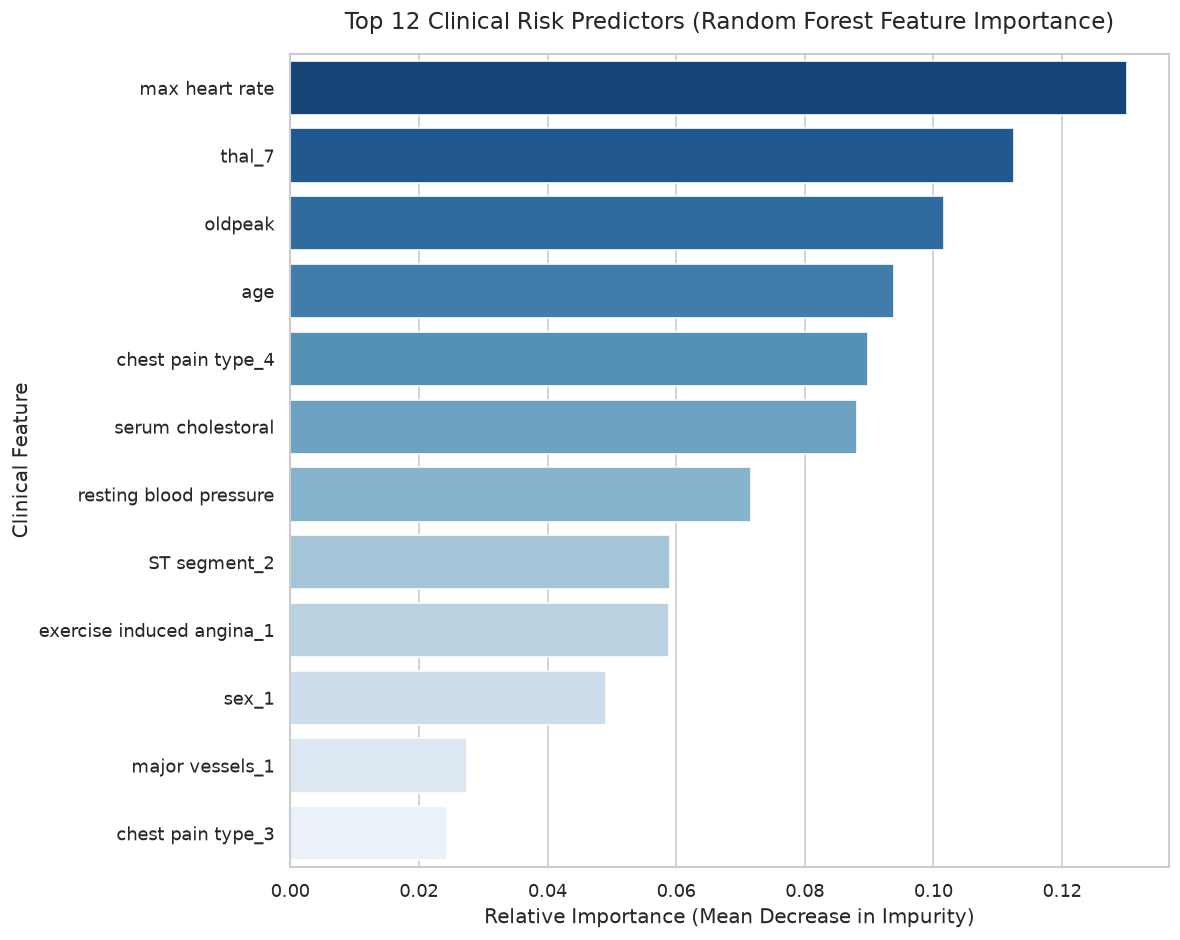

In [19]:
# Extract feature names after One-Hot Encoding
preprocessor = rf_pipeline.named_steps['preprocessor']
cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = list(cat_encoder.get_feature_names_out(categorical_cols))
all_feature_names = numerical_cols + cat_feature_names

# Extract feature importances from Random Forest
rf_model = rf_pipeline.named_steps['classifier']
importances = rf_model.feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Display Top 10 Features
print("=== Top 10 Most Influential Features (Random Forest) ===")
print(feat_imp_df.head(10).to_string(index=False))

# Horizontal Bar Plot
plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp_df.head(12), x='Importance', y='Feature', palette='Blues_r')
plt.title('Top 12 Clinical Risk Predictors (Random Forest Feature Importance)', pad=15)
plt.xlabel('Relative Importance (Mean Decrease in Impurity)')
plt.ylabel('Clinical Feature')
plt.tight_layout()
plt.show()

> **Clinical Discussion of Top Predictors**:
> 1. **`max heart rate`**: Chronotropic incompetence (inability to reach expected maximum heart rate during exercise) is a well-established physiological sign of coronary ischemia.
> 2. **`thal_7` (Reversible Thallium Defect)**: Indicates transient myocardial ischemia where perfusion returns after rest, a hallmark of reversible coronary obstruction.
> 3. **`oldpeak`**: Magnitude of ST segment depression during stress reflects the severity and extent of exercise-induced myocardial oxygen deprivation.
> 4. **`age`**: Independent vascular aging risk factor contributing to arterial stiffness and atherosclerotic plaque burden.
> 5. **`chest pain type_4` (Asymptomatic)**: Clinically counterintuitive at first glance, but patients presenting with asymptomatic ischemia often suffer from advanced multivessel disease that went unmanaged due to absence of typical warning angina.

---
## 18. Model Comparison Across Evaluation Metrics

To provide a comprehensive side-by-side synthesis, we plot all five calculated metrics across the three evaluated classifiers.

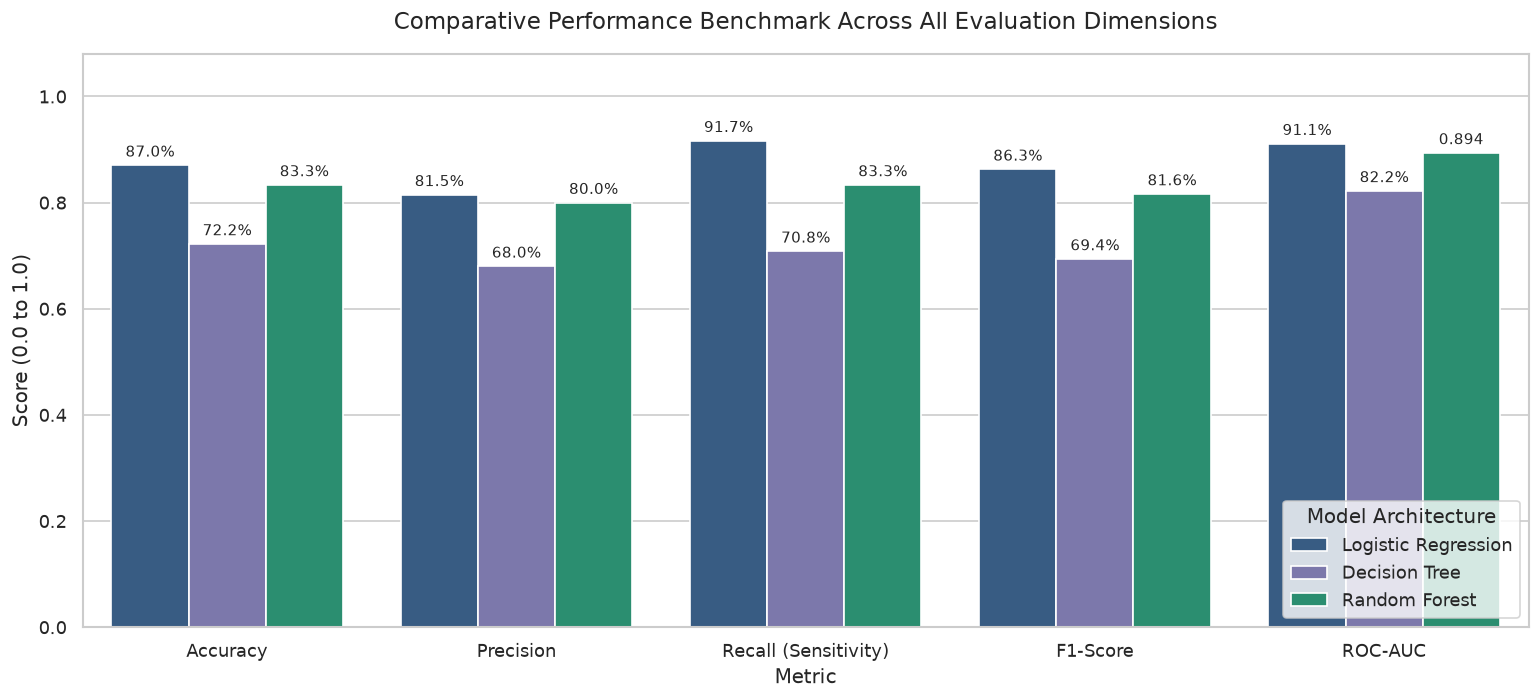

In [20]:
# Melt dataframe for multi-bar seaborn visualization
melted_df = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(13, 6))
bar_plot = sns.barplot(data=melted_df, x='Metric', y='Score', hue='Model',
                       palette=['#2b5c8f', '#7570b3', '#1b9e77'])

plt.title('Comparative Performance Benchmark Across All Evaluation Dimensions', pad=15)
plt.ylabel('Score (0.0 to 1.0)')
plt.ylim(0, 1.08)
plt.legend(title='Model Architecture', loc='lower right', frameon=True)

# Add score annotations above each bar
for p in bar_plot.patches:
    h = p.get_height()
    if h > 0:
        bar_plot.annotate(f"{h:.1%}" if p.get_x() < 4 else f"{h:.3f}",
                          (p.get_x() + p.get_width() / 2., h),
                          ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                          textcoords='offset points')

plt.tight_layout()
plt.show()

---
## 19. Final Conclusion & Model Selection

### Metric Summary on Test Set ($N = 54$):
| Model | Accuracy | Precision | Recall (Sensitivity) | F1-Score | ROC-AUC | False Negatives |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression** | **87.04%** | **81.48%** | **91.67%** | **86.27%** | **0.9111** | **2** |
| **Random Forest** | 83.33% | 80.00% | 83.33% | 81.63% | 0.8938 | 4 |
| **Decision Tree** | 72.22% | 68.00% | 70.83% | 69.39% | 0.8222 | 7 |

---

### Key Takeaways & Selection Justification:

1. **Top Performing Candidate: Regularized Logistic Regression**
   - **Diagnostic Sensitivity (Recall)**: Logistic Regression delivered the highest Recall at **91.67%**, successfully detecting 22 out of 24 heart disease patients and misclassifying only 2.
   - **Discrimination (ROC-AUC)**: At **0.9111**, it demonstrates outstanding capability to rank patients across all operating thresholds.
   - **Generalization**: L2-regularized linear models excel on tabular datasets with moderate sample sizes ($N=270$). Because linear models have lower variance than unconstrained trees, they are naturally resilient against overfitting small samples.

2. **Ensemble Utility (Random Forest)**
   - Random Forest achieved respectable accuracy (**83.33%**) and ROC-AUC (**0.8938**), demonstrating solid capability without hyperparameter fine-tuning.
   - It served as our primary vehicle for non-linear feature attribution, corroborating cardiological domain literature regarding thallium defects and maximum heart rate reserve.

3. **Suboptimal Candidate (Decision Tree)**
   - Despite pruning (`max_depth=4`, `min_samples_split=10`), the single Decision Tree lagged across all dimensions (Accuracy: 72.22%, Recall: 70.83%), suffering from high decision boundary rigidity.

---
## 20. Clinical & Methodological Limitations

While the pipeline demonstrates strong classification capability and sound methodology, several limitations must be acknowledged before any hypothetical translation into clinical workflows:

1. **Sample Size & Statistical Power**:
   - The dataset contains only **270 patients** (216 train, 54 test). While sufficient for educational benchmarking and foundational machine learning, a larger cohort ($N > 10,000$) is necessary to capture rare clinical sub-phenotypes.

2. **External & Prospective Validation**:
   - The data originates from a single historical multi-center study (Cleveland / Statlog). Performance must be independently validated on external geographic cohorts and modern electronic health record (EHR) databases to assess cross-population generalizability.

3. **Demographic & Diagnostic Representation**:
   - Historical cohorts often under-represent female cardiac symptoms (which frequently present with atypical angina rather than typical substernal chest pressure).
   - The dataset predates modern high-sensitivity cardiac biomarkers, such as:
     - High-sensitivity Cardiac Troponin I/T ($hs\text{-cTn}$)
     - B-type Natriuretic Peptide ($BNP / NT\text{-proBNP}$)
     - Coronary Artery Calcium ($CAC$) scoring via CT angiogram.

4. **Integration as a Clinical Decision Support System (CDSS)**:
   - This model is intended solely to serve as a **screening triage tool** to prioritize patients for diagnostic angiography, not as an autonomous diagnostic authority. The final clinical determination must always remain with the attending cardiologist.